NameError: name 'possion' is not defined

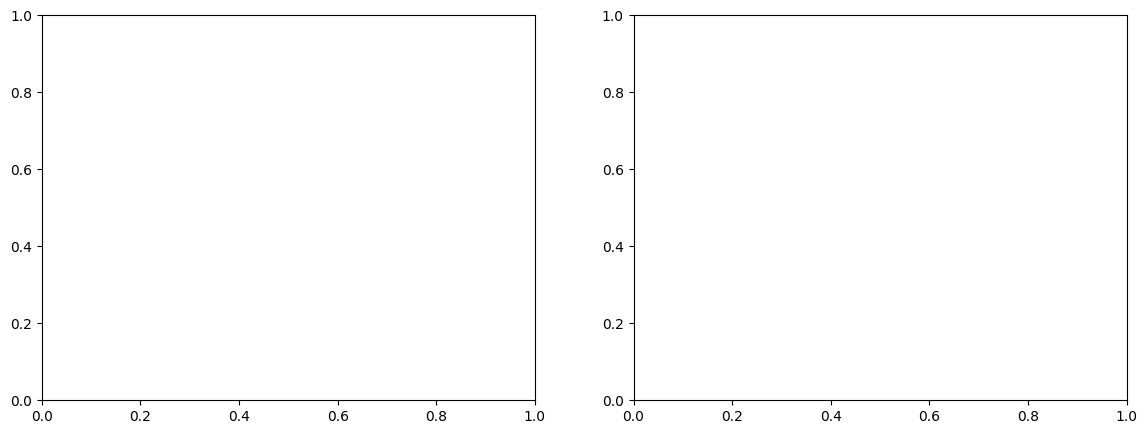

In [4]:
# needed libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial


# plotting
def parts_for_hw(section, ax):

    # Defining distribution functions
    def guassian(x, mean, std):  # Continuous
        prob = 1/(np.sqrt(2*np.pi*std**2)) * np.exp(-(x-mean)**2 / (2*std**2))
        return prob

    def poisson(n, mean):
        mean = float(mean)
        return mean**n / factorial(n) * np.exp(-mean)

    def binomial(n, N, p):  # Discrete
        prob = (
            factorial(N)
            / (factorial(n)*factorial(N-n))
            * p**n
            * (1-p)**(N-n)
        )
        return prob


    # spatial span [for Gaussian]
    dx = 0.001
    xi = 0
    xf = 10
    x = np.arange(xi, xf+dx, dx)

    # index span [for Poisson and Binomial]
    dn = 1
    ni = 0
    nf = 10
    n = np.arange(ni, nf+dn, dn)


    # pass variable through functions
    if section == 1:

        normal_dis = guassian(
            x=x,
            mean=1,
            std=0.5
        )

        binomial_dis = binomial(
            n=n,
            N=10,
            p=0.1
        )

        possion_dis = possion(
            n=n,
            mean=1.
        )

    elif section == 2:

        normal_dis = guassian(
            x=x,
            mean=2,
            std=1
        )

        binomial_dis = binomial(
            n=n,
            N=10,
            p=0.2
        )

        possion_dis = possion(
            n=n,
            mean=2.
        )

    else:
        raise ValueError("Not an option")


    # Gaussian
    ax.plot(
        x,
        normal_dis,
        color="Red",
        label="Gaussian Distribution"
    )

    # Poisson
    ax.plot(
        n,
        possion_dis,
        color="Purple",
        marker="o",
        ls="--",
        label="Poisson Distribution"
    )

    # Binomial
    ax.plot(
        n,
        binomial_dis,
        color="Green",
        marker="o",
        ls="--",
        label="Binomial Distribution"
    )


    # axis formatting
    ax.set_title(f"Section {section}: Comparing Distributions")

    ax.set_xlabel("Sample Value")
    ax.set_ylabel("Probability / Probability Density")

    ax.set_xlim(xi, xf)

    ax.legend(loc="best")
    ax.grid(ls="--")


# ============================================
# Create 1 x 2 array of plots
# ============================================

fig, ax = plt.subplots(
    1, 2,
    figsize=(14, 5)
)

# Left plot
parts_for_hw(1, ax[0])

# Right plot
parts_for_hw(2, ax[1])

plt.tight_layout()
plt.show()

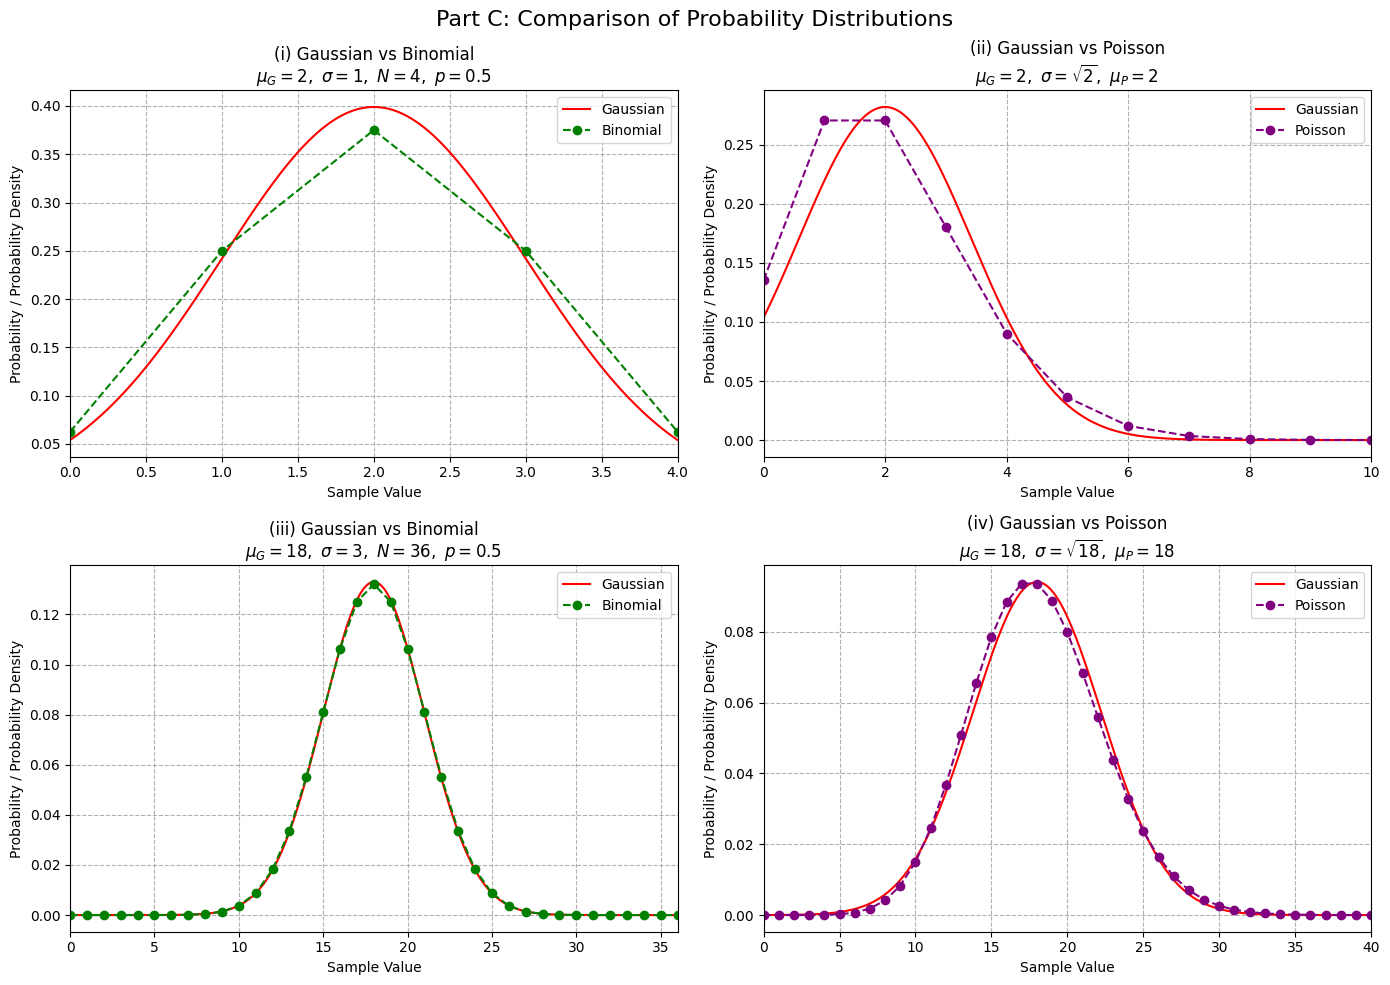

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial


# Distribution functions
def gaussian(x, mean, std):
    return (
        1 / np.sqrt(2 * np.pi * std**2)
        * np.exp(-(x - mean)**2 / (2 * std**2))
    )


def poisson(n, mean):
    mean = float(mean)
    return mean**n / factorial(n) * np.exp(-mean)


def binomial(n, N, p):
    return (
        factorial(N)
        / (factorial(n) * factorial(N - n))
        * p**n
        * (1 - p)**(N - n)
    )


def part_c(section, ax):

    # (i) Gaussian vs Binomial
    if section == 1:
        xi, xf = 0, 4

        x = np.linspace(xi, xf, 1000)
        n = np.arange(0, 5)

        gaussian_dis = gaussian(x, mean=2, std=1)
        binomial_dis = binomial(n, N=4, p=0.5)

        ax.plot(x, gaussian_dis, color="Red", label="Gaussian")
        ax.plot(
            n, binomial_dis,
            color="Green",
            marker="o",
            ls="--",
            label="Binomial"
        )

        ax.set_title(
            "(i) Gaussian vs Binomial\n"
            r"$\mu_G=2,\ \sigma=1,\ N=4,\ p=0.5$"
        )

    # (ii) Gaussian vs Poisson
    elif section == 2:
        xi, xf = 0, 10

        x = np.linspace(xi, xf, 1000)
        n = np.arange(0, 11)

        gaussian_dis = gaussian(x, mean=2, std=np.sqrt(2))
        poisson_dis = poisson(n, mean=2.)

        ax.plot(x, gaussian_dis, color="Red", label="Gaussian")
        ax.plot(
            n, poisson_dis,
            color="Purple",
            marker="o",
            ls="--",
            label="Poisson"
        )

        ax.set_title(
            "(ii) Gaussian vs Poisson\n"
            r"$\mu_G=2,\ \sigma=\sqrt{2},\ \mu_P=2$"
        )

    # (iii) Gaussian vs Binomial
    elif section == 3:
        xi, xf = 0, 36

        x = np.linspace(xi, xf, 2000)
        n = np.arange(0, 37)

        gaussian_dis = gaussian(x, mean=18, std=3)
        binomial_dis = binomial(n, N=36, p=0.5)

        ax.plot(x, gaussian_dis, color="Red", label="Gaussian")
        ax.plot(
            n, binomial_dis,
            color="Green",
            marker="o",
            ls="--",
            label="Binomial"
        )

        ax.set_title(
            "(iii) Gaussian vs Binomial\n"
            r"$\mu_G=18,\ \sigma=3,\ N=36,\ p=0.5$"
        )

    # (iv) Gaussian vs Poisson
    elif section == 4:
        xi, xf = 0, 40

        x = np.linspace(xi, xf, 2000)
        n = np.arange(0, 41)

        gaussian_dis = gaussian(x, mean=18, std=np.sqrt(18))
        poisson_dis = poisson(n, mean=18.)

        ax.plot(x, gaussian_dis, color="Red", label="Gaussian")
        ax.plot(
            n, poisson_dis,
            color="Purple",
            marker="o",
            ls="--",
            label="Poisson"
        )

        ax.set_title(
            "(iv) Gaussian vs Poisson\n"
            r"$\mu_G=18,\ \sigma=\sqrt{18},\ \mu_P=18$"
        )

    else:
        raise ValueError("Section must be 1, 2, 3, or 4")

    ax.set_xlabel("Sample Value")
    ax.set_ylabel("Probability / Probability Density")
    ax.set_xlim(xi, xf)
    ax.legend(loc="best")
    ax.grid(ls="--")


# 2 x 2 array of plots
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

part_c(1, ax[0, 0])
part_c(2, ax[0, 1])
part_c(3, ax[1, 0])
part_c(4, ax[1, 1])

fig.suptitle(
    "Part C: Comparison of Probability Distributions",
    fontsize=16
)

plt.tight_layout()
plt.show()